## **Importing Modules**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix,accuracy_score
from sklearn.tree import DecisionTreeClassifier 
from sklearn import metrics 
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier, VotingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

In [2]:
# Hide non-critical warnings to keep the notebook output clean without hiding important issues.
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## **Data Representation**

In [3]:
df = pd.read_csv('/kaggle/input/bmw-car-sales-dataset/BMW_Car_Sales_Classification.csv')

In [4]:
df.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  object 
 5   Transmission          50000 non-null  object 
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 4.2+ MB


In [6]:
df.describe()

,Year,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2017.015700,3.247180,100307.203140,75034.600900,5067.514680
std,4.324459,1.009078,57941.509344,25998.248882,2856.767125
min,2010.000000,1.500000,3.000000,30000.000000,100.000000
25%,2013.000000,2.400000,50178.000000,52434.750000,2588.000000
50%,2017.000000,3.200000,100388.500000,75011.500000,5087.000000
75%,2021.000000,4.100000,150630.250000,97628.250000,7537.250000
max,2024.000000,5.000000,199996.000000,119998.000000,9999.000000


In [7]:
df.isna().sum()

Model                   0
Year                    0
Region                  0
Color                   0
Fuel_Type               0
Transmission            0
Engine_Size_L           0
Mileage_KM              0
Price_USD               0
Sales_Volume            0
Sales_Classification    0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low


In [10]:
df['Model'].value_counts()

Model
7 Series    4666
i3          4618
i8          4606
3 Series    4595
5 Series    4592
X1          4570
X3          4497
X5          4487
M5          4478
X6          4478
M3          4413
Name: count, dtype: int64

In [11]:
df['Region'].value_counts()

Region
Asia             8454
Middle East      8373
North America    8335
Europe           8334
Africa           8253
South America    8251
Name: count, dtype: int64

In [12]:
df['Color'].value_counts()

Color
Red       8463
Silver    8350
Grey      8348
White     8304
Black     8273
Blue      8262
Name: count, dtype: int64

In [13]:
df['Fuel_Type'].value_counts()

Fuel_Type
Hybrid      12716
Petrol      12550
Electric    12471
Diesel      12263
Name: count, dtype: int64

In [14]:
Categorical_Columns = ['Color', 'Fuel_Type', 'Transmission', 'Region', 'Model','Sales_Classification']
Numeric_Columns = ['Engine_Size_L' ,'Mileage_KM', 'Price_USD', 'Sales_Volume']

## **Data Analysis**

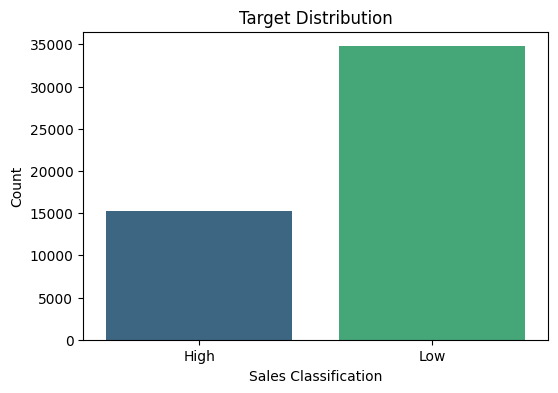

In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Sales_Classification', data=df, palette='viridis')
plt.title('Target Distribution')
plt.xlabel('Sales Classification')
plt.ylabel('Count')
plt.show()

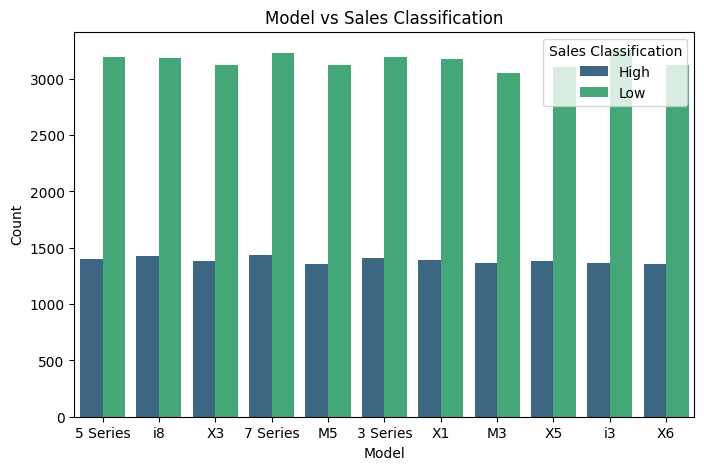

In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Model', hue='Sales_Classification', data=df, palette='viridis')
plt.title('Model vs Sales Classification')
plt.xlabel('Model')
plt.ylabel('Count')
plt.legend(title='Sales Classification')
plt.show()

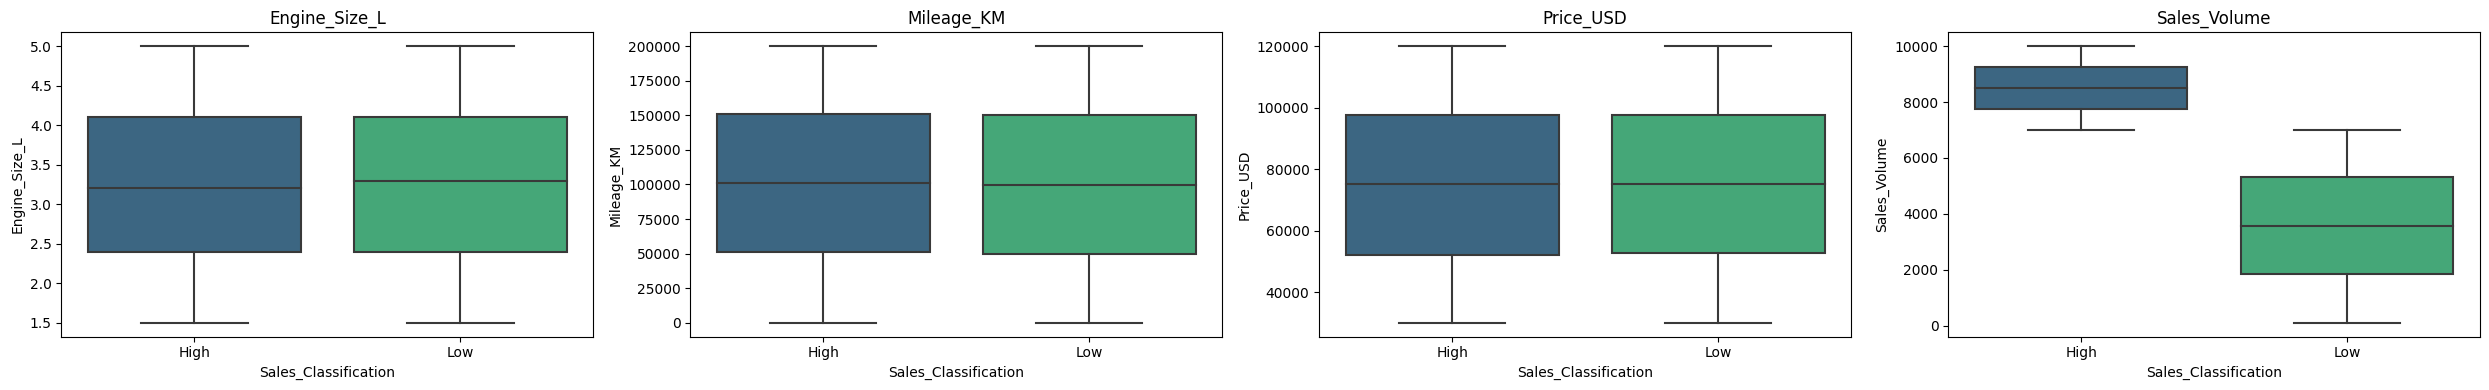

In [17]:
plt.figure(figsize=(25, 4))
for i in range(len(Numeric_Columns)):
    plt.subplot(1, len(Numeric_Columns), i+1)
    sns.boxplot(x='Sales_Classification', y=Numeric_Columns[i], data=df, palette='viridis')
    plt.title(Numeric_Columns[i])
plt.tight_layout()
plt.show()

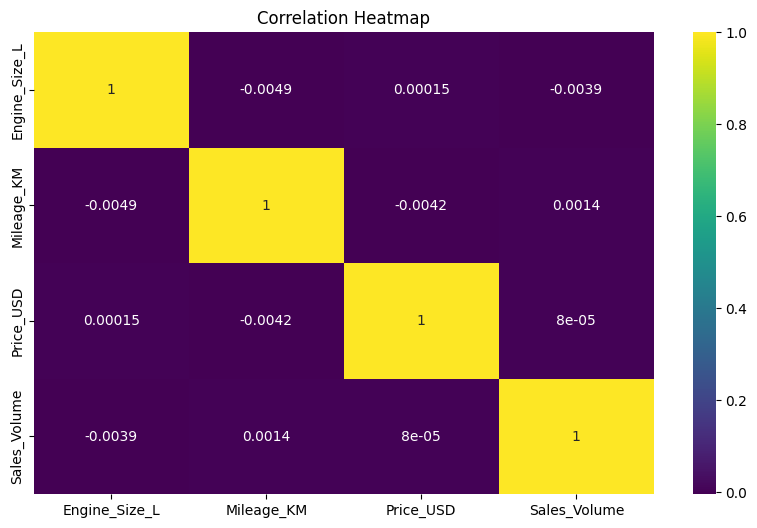

In [18]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[Numeric_Columns].corr(), annot=True, cmap='viridis')
plt.title('Correlation Heatmap')
plt.show()

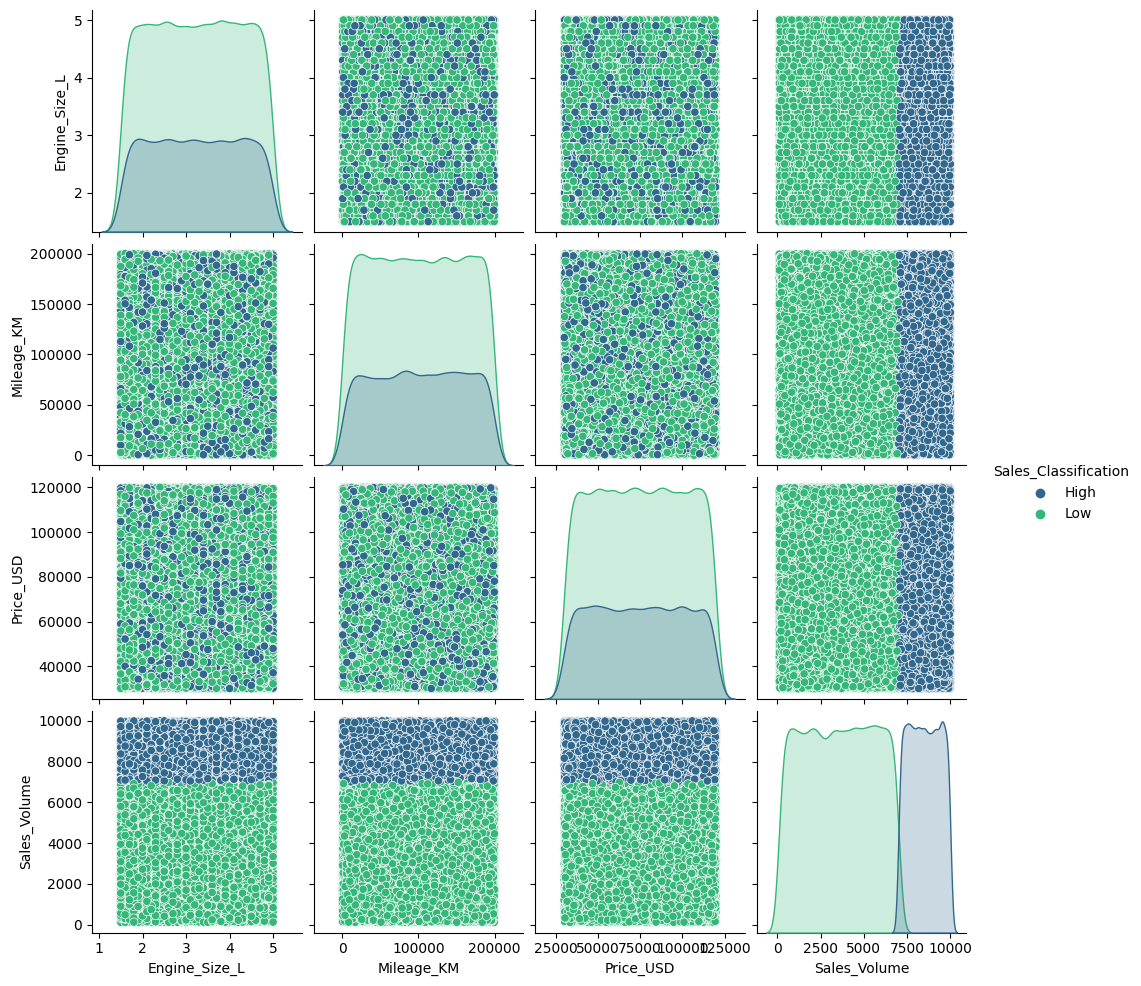

In [19]:
sns.pairplot(df[Numeric_Columns + ['Sales_Classification']], hue='Sales_Classification', palette='viridis')
plt.show()

## **Data Preprocessing**

In [20]:
for col in Categorical_Columns:
    Label = LabelEncoder()
    df[col] = Label.fit_transform(df[col])

In [21]:
scaler = MinMaxScaler()
df[Numeric_Columns] = scaler.fit_transform(df[Numeric_Columns])
df.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,1,2016,1,3,3,1,0.571429,0.758752,0.763795,0.828367,0
1,10,2013,4,3,2,0,0.028571,0.608361,0.546890,0.336196,1
2,1,2022,4,1,3,0,0.857143,0.054942,0.925187,0.696434,1
3,6,2024,3,1,3,0,0.057143,0.136265,0.344130,0.398727,1
4,2,2020,5,0,0,1,0.171429,0.610661,0.221094,0.301041,1


## **Data Splitting**

In [22]:
Feature = df.drop(columns='Sales_Classification')
Target = df['Sales_Classification']

In [23]:
x_train, x_test, y_train, y_test = train_test_split(Feature, Target , test_size = 0.2)

## **Data Modeling**

Logistic Regression

In [24]:
Logistic_Model = LogisticRegression()
Logistic_Model.fit(x_train,y_train)

LogisticRegression()

In [25]:
y_pred = Logistic_Model.predict(x_test)

In [26]:
Logistic_Model.score(x_train,y_train)

0.996575

In [27]:
Logistic_Model.score(x_test,y_test)

0.9966

SVM

In [28]:
SVM_Model = SVC(C=200, kernel='rbf', gamma='scale')
SVM_Model.fit(x_train, y_train)

SVC(C=200)

In [29]:
SVM_Model.score(x_train,y_train)

0.696725

In [30]:
SVM_Model.score(x_test,y_test)

0.6885

Decision Tree

In [31]:
DT = DecisionTreeClassifier(criterion="gini", max_depth=3)
DT = DT.fit(x_train, y_train)

In [32]:
y_pred = DT.predict(x_test)

In [33]:
accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 1.00


Naive Bayes

In [34]:
GNB = GaussianNB()
GNB.fit(x_train, y_train)

GaussianNB()

In [35]:
y_pred = GNB.predict(x_test)

In [36]:
accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 1.00


Random Forest

In [38]:
Random_Forest = RandomForestClassifier(n_estimators=50, max_depth=4, random_state=42)
Random_Forest.fit(x_train, y_train)

RandomForestClassifier(max_depth=4, n_estimators=50, random_state=42)

In [39]:
Random_Forest.score(x_train, y_train)

1.0

In [40]:
Random_Forest.score(x_test, y_test)

1.0

Extra Trees 

In [41]:
ET = ExtraTreesClassifier(n_estimators=30, max_depth=4, random_state=101)
ET.fit(x_train, y_train)

ExtraTreesClassifier(max_depth=4, n_estimators=30, random_state=101)

In [42]:
ET.score(x_train, y_train)

0.88895

In [43]:
ET.score(x_test, y_test)

0.8881

Bagging

In [44]:
BC = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=4), n_estimators=200, random_state=101)

BC.fit(x_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=4),
                  n_estimators=200, random_state=101)

In [45]:
BC.score(x_train, y_train)

1.0

In [46]:
BC.score(x_test, y_test)

1.0

XGB

In [47]:
XGB = XGBClassifier(n_estimators=20, max_depth=4, random_state=42)
XGB.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=20, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [48]:
XGB.score(x_train, y_train)

0.99955

In [49]:
XGB.score(x_test, y_test)

0.9981

Cat Boost

In [50]:
CBC = CatBoostClassifier(n_estimators=300, max_depth=4, random_state=42)
CBC.fit(x_train, y_train)

Learning rate set to 0.150139
0:	learn: 0.2822417	total: 63.3ms	remaining: 18.9s
1:	learn: 0.1279947	total: 70.4ms	remaining: 10.5s
2:	learn: 0.0595297	total: 77.2ms	remaining: 7.64s
3:	learn: 0.0329554	total: 83.6ms	remaining: 6.19s
4:	learn: 0.0185486	total: 91.6ms	remaining: 5.41s
5:	learn: 0.0127017	total: 98.1ms	remaining: 4.81s
6:	learn: 0.0086335	total: 105ms	remaining: 4.38s
7:	learn: 0.0057833	total: 111ms	remaining: 4.05s
8:	learn: 0.0045141	total: 117ms	remaining: 3.79s
9:	learn: 0.0038161	total: 124ms	remaining: 3.58s
10:	learn: 0.0034187	total: 130ms	remaining: 3.41s
11:	learn: 0.0030286	total: 138ms	remaining: 3.32s
12:	learn: 0.0027975	total: 145ms	remaining: 3.21s
13:	learn: 0.0027671	total: 153ms	remaining: 3.12s
14:	learn: 0.0027047	total: 158ms	remaining: 3.01s
15:	learn: 0.0025634	total: 165ms	remaining: 2.93s
16:	learn: 0.0024966	total: 171ms	remaining: 2.85s
17:	learn: 0.0024383	total: 177ms	remaining: 2.78s
18:	learn: 0.0023801	total: 185ms	remaining: 2.73s
19:	l

In [51]:
CBC.score(x_train, y_train)

0.999675

In [52]:
CBC.score(x_test, y_test)

0.9985

Ada Boost

In [53]:
ABC = AdaBoostClassifier(estimator=CatBoostClassifier(n_estimators=300, max_depth=4, random_state=42), n_estimators=50, random_state=42)

ABC.fit(x_train, y_train)

Learning rate set to 0.150139
0:	learn: 0.2411660	total: 8.55ms	remaining: 2.56s
1:	learn: 0.0894572	total: 15ms	remaining: 2.24s
2:	learn: 0.0355575	total: 21.6ms	remaining: 2.14s
3:	learn: 0.0167509	total: 28ms	remaining: 2.07s
4:	learn: 0.0091106	total: 34.8ms	remaining: 2.05s
5:	learn: 0.0059668	total: 41.4ms	remaining: 2.03s
6:	learn: 0.0042767	total: 47.9ms	remaining: 2.01s
7:	learn: 0.0034014	total: 54.1ms	remaining: 1.97s
8:	learn: 0.0030012	total: 60.7ms	remaining: 1.96s
9:	learn: 0.0027644	total: 67.6ms	remaining: 1.96s
10:	learn: 0.0025761	total: 73.3ms	remaining: 1.93s
11:	learn: 0.0024397	total: 81.1ms	remaining: 1.95s
12:	learn: 0.0023553	total: 87.5ms	remaining: 1.93s
13:	learn: 0.0022596	total: 94.2ms	remaining: 1.92s
14:	learn: 0.0021900	total: 100ms	remaining: 1.91s
15:	learn: 0.0021145	total: 107ms	remaining: 1.91s
16:	learn: 0.0020693	total: 115ms	remaining: 1.91s
17:	learn: 0.0020374	total: 120ms	remaining: 1.89s
18:	learn: 0.0020373	total: 125ms	remaining: 1.85s
1

AdaBoostClassifier(estimator=<catboost.core.CatBoostClassifier object at 0x7a63373a33d0>,
                   random_state=42)

In [54]:
ABC.score(x_train,y_train)

1.0

In [55]:
ABC.score(x_test,y_test)

0.9985

LGBM

In [56]:
LGM = LGBMClassifier(n_estimators=50, max_depth=5, random_state=42)
LGM.fit(x_train, y_train)

[LightGBM] [Info] Number of positive: 27869, number of negative: 12131
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001996 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 846
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.696725 -> initscore=0.831751
[LightGBM] [Info] Start training from score 0.831751
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

LGBMClassifier(max_depth=5, n_estimators=50, random_state=42)

In [57]:
LGM.score(x_train, y_train)

0.999475

In [58]:
LGM.score(x_test, y_test)

0.998

Voting

In [59]:
estimators = [('svm', SVC(C=10, kernel='rbf', gamma='scale')),
              ('dt', DecisionTreeClassifier(max_depth=4)),
              ('lr', LogisticRegression()),
              ('dt2', DecisionTreeClassifier(max_depth=5))]

VC = VotingClassifier(estimators=estimators)
VC.fit(x_train, y_train)

VotingClassifier(estimators=[('svm', SVC(C=10)),
                             ('dt', DecisionTreeClassifier(max_depth=4)),
                             ('lr', LogisticRegression()),
                             ('dt2', DecisionTreeClassifier(max_depth=5))])

In [60]:
VC.score(x_train, y_train)

1.0

In [61]:
VC.score(x_test, y_test)

1.0